# Notebook 12 - baseline models

Dr Talebi asked for the deep models to be compared against some standard time-series baselines, not just persistence. So this notebook adds a proper set of simple baselines and puts them all in one table with the LSTM and TFT.

Baselines:
- persistence (naive) - forecast = last observed temperature, held flat for 24h
- seasonal naive - forecast = the same hour 24h earlier (tomorrow looks like today)
- climatology - forecast = the training-set average temperature for that city/month/hour
- linear regression - direct multi-output on the engineered features
- gradient boosting - HistGradientBoostingRegressor, one per horizon

Everything is evaluated the same way as the deep models: all 5 cities, 24-hour horizon, MAE / RMSE / R2 on the test split.

I did think about ARIMA/SARIMA but with hourly data that has both a daily and a yearly cycle, seasonal ARIMA is very slow to fit and needs two seasonal periods. The seasonal-naive and climatology baselines cover the statistical side well enough for the comparison, so I left ARIMA out for now.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT, 'processed')
PLOTS = os.path.join(ROOT, 'plots')

In [2]:
master = pd.read_csv(os.path.join(PROC, 'master_all_cities.csv'),
                     parse_dates=['time'], low_memory=False)
master = master.sort_values(['city', 'time']).reset_index(drop=True)
print(master.shape)
print(master['city'].unique())

(438240, 45)
<ArrowStringArray>
['Jena', 'London', 'New_York', 'Sydney', 'Tokyo']
Length: 5, dtype: str


In [3]:
CITIES = ['Jena', 'London', 'New_York', 'Sydney', 'Tokyo']
SEQ = 168   # same 1-week history as the deep models
H = 24      # forecast horizon

# features known at the forecast origin (no future info). these are the engineered
# columns the master table already has.
FEATS = [
    'temperature', 'humidity', 'dew_point', 'precipitation',
    'wind_speed', 'wind_gusts', 'wind_u', 'wind_v',
    'pressure_msl', 'surface_pressure',
    'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    'shortwave_radiation', 'direct_radiation',
    'vapour_pressure_deficit', 'wet_bulb_temp', 'water_vapour', 'soil_temperature',
    'temp_lag_1h', 'temp_lag_3h', 'temp_lag_6h', 'temp_lag_24h',
    'temp_roll_6h', 'temp_roll_24h', 'temp_diff_1h',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos',
    'lat', 'lon',
]
missing = [c for c in FEATS if c not in master.columns]
print('missing feature cols:', missing)
print('n features:', len(FEATS))

missing feature cols: []
n features: 35


## build the windows

For each city, forecast origin o has the previous week as history and the next 24 hours as the target. Train origins keep both history and target inside the training region (no leakage), test origins sit in the last 15%. Same 70/15/15 chronological split as everywhere else.

In [4]:
# collect everything here
Xtr_all, Ytr_all = [], []
Xte_all, Yte_all = [], []
persist_all, snaive_all, clim_all = [], [], []
test_city_all = []

for city in CITIES:
    d = master[master['city'] == city].reset_index(drop=True)
    T = d['temperature'].values.astype(float)
    feats = d[FEATS].values.astype(float)
    month = d['time'].dt.month.values
    hour = d['time'].dt.hour.values
    n = len(T)

    tr_end = int(n * 0.70)
    val_end = int(n * 0.85)

    # climatology lookup from the training region only
    clim_df = pd.DataFrame({'m': month[:tr_end], 'h': hour[:tr_end], 't': T[:tr_end]})
    clim_tab = clim_df.groupby(['m', 'h'])['t'].mean()
    # map every row to its climatology value
    C = np.array([clim_tab.get((month[k], hour[k]), T[:tr_end].mean()) for k in range(n)])

    # sliding windows
    targ = sliding_window_view(T, H)     # targ[j] = T[j:j+H]
    win24 = sliding_window_view(T, 24)   # win24[j] = T[j:j+24]
    climH = sliding_window_view(C, H)    # climH[j] = C[j:j+H]

    # valid origins: need 168h history behind, and 24h target ahead
    o_all = np.arange(SEQ - 1, n - H - 1)
    tr_o = o_all[(o_all + H) < tr_end]        # whole window inside train
    te_o = o_all[o_all >= val_end]            # origin in test region

    # targets (next 24h starting at o+1)
    def targets(origins):
        return targ[origins + 1]

    Xtr_all.append(feats[tr_o]);   Ytr_all.append(targets(tr_o))
    Xte_all.append(feats[te_o]);   Yte_all.append(targets(te_o))

    # cheap baselines on the test origins
    persist_all.append(np.repeat(T[te_o][:, None], H, axis=1))
    snaive_all.append(win24[te_o - 23])       # last 24 observed hours
    clim_all.append(climH[te_o + 1])
    test_city_all.append(np.array([city] * len(te_o)))

    print(f'{city:10s} train origins {len(tr_o):6d}  test origins {len(te_o):6d}')

Jena       train origins  61162  test origins  13123


London     train origins  61162  test origins  13123


New_York   train origins  61162  test origins  13123


Sydney     train origins  61162  test origins  13123


Tokyo      train origins  61162  test origins  13123


In [5]:
Xtr = np.concatenate(Xtr_all); Ytr = np.concatenate(Ytr_all)
Xte = np.concatenate(Xte_all); Yte = np.concatenate(Yte_all)
persist = np.concatenate(persist_all)
snaive = np.concatenate(snaive_all)
clim = np.concatenate(clim_all)
test_city = np.concatenate(test_city_all)

print('train X:', Xtr.shape, ' test X:', Xte.shape)
print('test targets:', Yte.shape)

train X: (305810, 35)  test X: (65615, 35)
test targets: (65615, 24)


## the ML baselines

Linear regression and gradient boosting, both predicting all 24 horizons at once (direct multi-output). Subsampling the training origins a bit so the gradient boosting doesn't take forever on the laptop - 24 separate models is the slow part.

In [6]:
# subsample training rows for speed (every 3rd origin)
sub = np.arange(0, len(Xtr), 3)
Xtr_s, Ytr_s = Xtr[sub], Ytr[sub]
print('training on', Xtr_s.shape[0], 'windows')

# linear regression - instant, handles multi-output natively
lin = LinearRegression()
lin.fit(Xtr_s, Ytr_s)
lin_pred = lin.predict(Xte)
print('linear done')

training on 101937 windows


linear done


In [7]:
# gradient boosting - one model per horizon via MultiOutputRegressor
gbm = MultiOutputRegressor(
    HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1,
                                  early_stopping=True, random_state=42),
    n_jobs=-1,
)
gbm.fit(Xtr_s, Ytr_s)
gbm_pred = gbm.predict(Xte)
print('gbm done')

gbm done


## score everything

In [8]:
def score(name, pred):
    a = Yte.flatten()
    p = pred.flatten()
    m = np.isfinite(a) & np.isfinite(p)
    return {
        'model': name,
        'MAE': round(mean_absolute_error(a[m], p[m]), 4),
        'RMSE': round(float(np.sqrt(mean_squared_error(a[m], p[m]))), 4),
        'R2': round(r2_score(a[m], p[m]), 4),
    }

results = [
    score('Persistence', persist),
    score('Seasonal naive', snaive),
    score('Climatology', clim),
    score('Linear regression', lin_pred),
    score('Gradient boosting', gbm_pred),
]
res = pd.DataFrame(results)
print(res.to_string(index=False))

            model    MAE   RMSE     R2
      Persistence 2.9351 3.8600 0.7695
   Seasonal naive 2.0912 2.8886 0.8709
      Climatology 2.4698 3.2672 0.8349
Linear regression 1.5748 2.1610 0.9278
Gradient boosting 1.2580 1.7624 0.9520


In [9]:
# add the deep models from the earlier notebooks so it's all in one table
deep = pd.DataFrame([
    {'model': 'LSTM',        'MAE': 1.39, 'RMSE': 1.92, 'R2': 0.94},
    {'model': 'TFT (tuned)', 'MAE': 1.53, 'RMSE': 2.16, 'R2': 0.93},
])
full = pd.concat([res, deep], ignore_index=True).sort_values('MAE').reset_index(drop=True)
print(full.to_string(index=False))
full.to_csv(os.path.join(PROC, 'baseline_results.csv'), index=False)

            model    MAE   RMSE     R2
Gradient boosting 1.2580 1.7624 0.9520
             LSTM 1.3900 1.9200 0.9400
      TFT (tuned) 1.5300 2.1600 0.9300
Linear regression 1.5748 2.1610 0.9278
   Seasonal naive 2.0912 2.8886 0.8709
      Climatology 2.4698 3.2672 0.8349
      Persistence 2.9351 3.8600 0.7695


In [10]:
# per-city MAE for the baselines, to compare with the deep models' per-city numbers
rows = []
for city in CITIES:
    mask = test_city == city
    row = {'city': city}
    for name, pred in [('persistence', persist), ('seasonal_naive', snaive),
                       ('climatology', clim), ('linear', lin_pred), ('gbm', gbm_pred)]:
        a = Yte[mask].flatten(); p = pred[mask].flatten()
        m = np.isfinite(a) & np.isfinite(p)
        row[name] = round(mean_absolute_error(a[m], p[m]), 3)
    rows.append(row)
per_city = pd.DataFrame(rows)
print(per_city.to_string(index=False))
per_city.to_csv(os.path.join(PROC, 'baseline_per_city.csv'), index=False)

    city  persistence  seasonal_naive  climatology  linear   gbm
    Jena        2.898           2.132        2.872   1.626 1.291
  London        2.740           1.853        2.259   1.445 1.198
New_York        3.396           2.799        3.140   1.890 1.510
  Sydney        2.791           1.897        1.996   1.566 1.182
   Tokyo        2.851           1.775        2.083   1.347 1.110


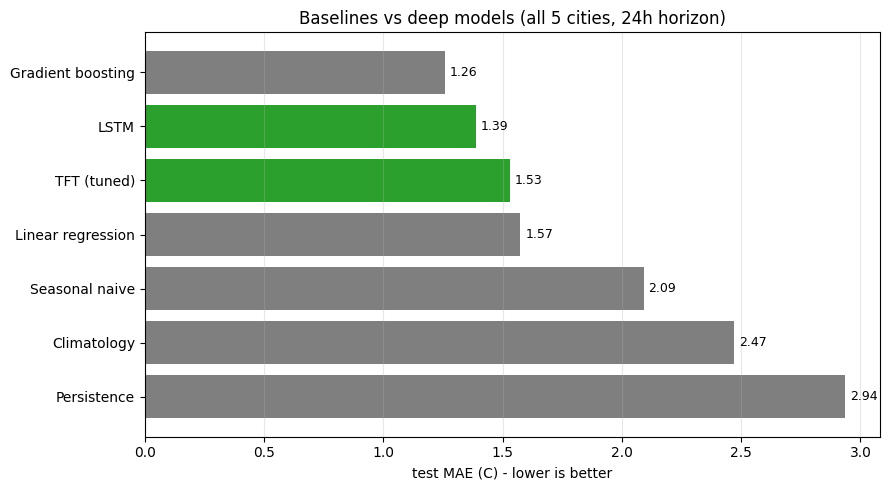

In [11]:
# bar chart, baselines vs deep models
order = full.sort_values('MAE')
colors = ['tab:green' if m in ('LSTM', 'TFT (tuned)') else 'tab:gray' for m in order['model']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(order['model'], order['MAE'], color=colors)
ax.set_xlabel('test MAE (C) - lower is better')
ax.set_title('Baselines vs deep models (all 5 cities, 24h horizon)')
ax.invert_yaxis()
for i, v in enumerate(order['MAE']):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS, 'baseline_comparison.png'), dpi=150)
plt.show()

## wrap up

Ranking by test MAE (all 5 cities, 24h):

- Gradient boosting 1.26
- LSTM 1.39
- TFT tuned 1.53
- Linear regression 1.57
- Seasonal naive 2.09
- Climatology 2.47
- Persistence 2.94

Two things stand out. First, every trained model clears the naive baselines comfortably, so the models are learning something real, not just copying yesterday. Second, and more interesting, the gradient boosting baseline actually beats both deep models. So the honest answer to the question I wrote earlier is that the LSTM is not beating a well set up tree model on point accuracy, it only beats the simple statistical ones.

That is a useful result to report rather than hide. Gradient boosting is known to be very strong on tabular data with good engineered features (the lag and rolling-mean columns do a lot of work here), so this is not surprising. It reframes where the deep models add value - probably in the probabilistic intervals (conformal, RQ4) and the built-in interpretability of the TFT (RQ3), not in raw MAE.

Caveat: the LSTM and TFT numbers here are taken from their own notebooks, which use their own dataloaders. The split, cities and horizon are the same, but the exact windowing is not identical, so this is a close comparison rather than a perfectly matched one. To make it airtight I should re-score the LSTM on exactly these test windows. Noting that as the next step.

Saved: processed/baseline_results.csv, processed/baseline_per_city.csv, plots/baseline_comparison.png